In [1]:
import os
import shutil
import sys

from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel, Field

from typing import List, Dict, Any, Optional

In [4]:

class Task(BaseModel):
    filename: str = Field(..., description="The name of the file associated with the task")
    file_path: str = Field(..., description="The path to the file associated with the task")
    description: str = Field(..., description="A detailed description of the task to be performed")

class Orchastrator_MOdel(BaseModel):
    plan: str = Field(..., description="a detailed plan to create the website application")
    tasks: List[Task]
class State(BaseModel):
    topic: str = Field(..., description="user prompt to create website application")
    plan: str = Field(..., description="a detailed plan to create the website application")
    tasks: List[Task]
    

In [3]:
# Defining the LLM
from langchain_aws import ChatBedrockConverse
from dotenv import load_dotenv
load_dotenv()

LLM_MODEL_ID = "us.meta.llama3-3-70b-instruct-v1:0"
LLM_CODER_MODEL_ID = "arn:aws:bedrock:us-east-1:868522398119:inference-profile/us.meta.llama3-2-1b-instruct-v1:0"
LLM_CODER_MODEL_ID2="anthropic.claude-3-haiku-20240307-v1:0"
LLM_REGION = "us-east-1"
llm=ChatBedrockConverse(
    model=LLM_MODEL_ID,
    region_name=LLM_REGION,
)


In [19]:
from langchain_core.messages import SystemMessage
import json
def orchastrator(state:State)->State:
    plan_prompt = f"Given the topic '{state.topic}', create a detailed plan to create a website application. \
        Also generate Tasks to send to the worker nodes so that they can work parallelly. The plan should be comprehensive and cover all necessary steps to achieve the goal."
    
    llm_=llm.with_structured_output(Orchastrator_MOdel)
    orchestrator_output = llm_.invoke([SystemMessage(content=plan_prompt)])
    print(orchestrator_output)
    state.plan = orchestrator_output.plan
    state.tasks = orchestrator_output.tasks
    
    return state

In [20]:
graph=StateGraph(State)
graph.add_node("orchastrator", orchastrator)
graph.add_edge(START, "orchastrator")
graph.add_edge("orchastrator", END)


graph=graph.compile()


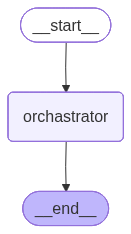

In [21]:
graph

In [22]:
png_data = graph.get_graph().draw_mermaid_png()
with open("workflow_graph.png", "wb") as f:
    f.write(png_data)

png_data

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\x83\x00\x00\x00\xea\x08\x02\x00\x00\x00\x0e\x04a\xa3\x00\x00\x10\x00IDATx\x9c\xec\x9d\x07\\\x13g\x1f\xc7\x9fK\xc8 \x08\xc8\xde \x88(C\xc5\xf5j\xad\xbe\xfa\xbaG\xaduVE\xeb\xab\xd6\xba\xeb\xa8Uk\xdd\xd6\xadm\xdf\xb7\xbe\xc5j\xad\x0b\xad\x03\xabX\xab\xa8u\xd0VQq\x80\xe2F\x04\x04\x91\xbd\x02\xd9w\xef?9\x8c\x11\x92\x14\xc8\x1d^\xc2}?\x1a.\xcf\xca\xdd\xf3\xbbg/+\x82 \x10\x0b\x03\xb0B,\xcc\x80U\x82)\xb0J0\x05V\t\xa6\xc0*\xc1\x14X%\x98B=)q\xedL\xfe\xcbgRY\x05\xaeR\x12r\x19\x810\x844\x95g\x8c\x83\x118\xc1\x81O5\x08\xc3\x90\xfa\xf3\x95!\\\xa8\x9488\x83k\x1c\'\xb4\x17`C\x80\x0f\xbc2p\xae\x158#H+\xd2/i\x0e&\xf0Iz\xc40\xf5O`\x1c\x04\xbe\xe0W\xe0\xbf\xd6\x99n\xf8Z\xb8|p\x8bx|\xcc\xc9\x93\x1f\xfa\x8e\xbd\x9b\xaf5\xa2\x19\x8c\xd6\xf6DLdfN\x86L!\'\xacx\x88/\xe4\xc2\x83\xc1C\xe3r]%4Q\x03\x11\x01\xd1\xf4\xa6\x12\xea\x98\x00[%\xe9\xac2\xe2H\xf7\xe0]\xed\xf2\x95\x12\x1c+\x0cW\x12\xaf\xfc\xbe6W_\xc3\x1f\xcdW][\x02\xeeB\xc7;\x00&\xd8\x9b\xd1\xc0\xe1!B\x85K\xa

In [23]:

temp_task=Task(filename="index.html", file_path="/path/to/index.html", description="Create the main HTML file for the bakery website.")
state=State(topic="Create a website application for a local bakery that includes features such as an online menu, ordering system, and contact information.", plan="", tasks=[temp_task])
graph.invoke(state)

plan='Create a website application for a local bakery that includes features such as an online menu, ordering system, and contact information. The plan should include the following steps: 1. Define the requirements and goals of the website application, 2. Design the user interface and user experience, 3. Develop the online menu and ordering system, 4. Implement the contact information and other features, 5. Test and deploy the website application' tasks=[Task(filename='menu_design', file_path='/menu/design', description='Design the online menu feature'), Task(filename='ordering_system', file_path='/ordering/system', description='Develop the ordering system feature'), Task(filename='contact_info', file_path='/contact/info', description='Implement the contact information feature')]


{'topic': 'Create a website application for a local bakery that includes features such as an online menu, ordering system, and contact information.',
 'plan': 'Create a website application for a local bakery that includes features such as an online menu, ordering system, and contact information. The plan should include the following steps: 1. Define the requirements and goals of the website application, 2. Design the user interface and user experience, 3. Develop the online menu and ordering system, 4. Implement the contact information and other features, 5. Test and deploy the website application',
 'tasks': [Task(filename='menu_design', file_path='/menu/design', description='Design the online menu feature'),
  Task(filename='ordering_system', file_path='/ordering/system', description='Develop the ordering system feature'),
  Task(filename='contact_info', file_path='/contact/info', description='Implement the contact information feature')]}